In [4]:
#SETUP
import pandas as pd
import pm4py
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pfad zur XES-Datei
FILE_PATH = "/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/BPI Challenge 2017_1_all/BPI Challenge 2017.xes.gz"

In [5]:
#DATENLADEN
log_df = pm4py.read_xes(FILE_PATH)

# Erste Inspektion
print(f"Überblick DataFrame")
print(f"Shape: {log_df.shape} (Zeilen, Spalten)")
print(f"\nSpalten:")
print(log_df.columns.tolist())
print(f"\nErste 5 Zeilen:")
print(log_df.head())
print(f"\nDatentypen:")
print(log_df.dtypes)


parsing log, completed traces :: 100%|██████████| 31509/31509 [00:20<00:00, 1532.73it/s]


Überblick DataFrame
Shape: (1202267, 19) (Zeilen, Spalten)

Spalten:
['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID']

Erste 5 Zeilen:
        Action org:resource            concept:name  EventOrigin  \
0      Created       User_1    A_Create Application  Application   
1  statechange       User_1             A_Submitted  Application   
2      Created       User_1          W_Handle leads     Workflow   
3      Deleted       User_1          W_Handle leads     Workflow   
4      Created       User_1  W_Complete application     Workflow   

                 EventID lifecycle:transition  \
0  Application_652823628             complete   
1   ApplState_1582051990             complete   
2    Workitem_1298499574             

In [7]:
#VARIANTEN-FILTERUNG
from pm4py.objects.conversion.log import converter as log_converter
event_log = log_converter.apply(log_df, variant=log_converter.Variants.TO_EVENT_LOG)
#FILTER: Entferne Cases ohne A_Cancelled, A_Pending oder A_Denied
required_activities = ['A_Cancelled', 'A_Pending', 'A_Denied']

print("Filter: Cases mit A_Cancelled, A_Pending oder A_Denied")
cases_before = len(event_log)

# Filtere Cases, die mindestens eine der erforderlichen Aktivitäten enthalten
filtered_traces = [trace for trace in event_log 
                   if any(activity in [event['concept:name'] for event in trace] 
                          for activity in required_activities)]

# Konvertiere zurück zu EventLog-Objekt
from pm4py.objects.log.obj import EventLog
event_log = EventLog(filtered_traces)

cases_after = len(event_log)
cases_removed = cases_before - cases_after

print(f"Gefunden: {cases_after:,} Cases")
print(f"Entfernt: {cases_removed:,} Cases")


Filter: Cases mit A_Cancelled, A_Pending oder A_Denied
Gefunden: 31,411 Cases
Entfernt: 98 Cases


In [8]:
# Konvertiere zu EventLog
print("Konvertiere zu EventLog...")
#event_log = log_converter.apply(event_log, variant=log_converter.Variants.TO_EVENT_LOG)
print(f"EventLog erstellt: {len(event_log):,} Fälle")

# Filtere Varianten nach Coverage
print("Varianten-Filterung nach Coverage")
coverage_percentage = 0.005 #first used 0.01 but this did not really do it, too less activities 

print(f"Filtere Varianten mit Coverage ≥ {coverage_percentage*100}%...")
filtered_log = pm4py.filter_variants_by_coverage_percentage(
    event_log,
    coverage_percentage,
    activity_key='concept:name',
    timestamp_key='time:timestamp',
    case_id_key='case:concept:name'
)

print(f"Original Log:")
print(f"Fälle: {len(event_log):,}")
print(f"Events: {sum(len(trace) for trace in event_log):,}")

print(f"Gefiltertes Log (Coverage ≥ {coverage_percentage*100}%):")
print(f"Fälle: {len(filtered_log):,} ({len(filtered_log)/len(event_log)*100:.1f}%)")
print(f"Events: {sum(len(trace) for trace in filtered_log):,}")


Konvertiere zu EventLog...
EventLog erstellt: 31,411 Fälle
Varianten-Filterung nach Coverage
Filtere Varianten mit Coverage ≥ 0.5%...
Original Log:
Fälle: 31,411
Events: 1,198,319
Gefiltertes Log (Coverage ≥ 0.5%):
Fälle: 5,000 (15.9%)
Events: 110,433


In [9]:
# Heuristic Miner auf gefiltertem Log
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

net_hm, im_hm, fm_hm = heuristics_miner.apply(
    filtered_log,
    parameters={'dependency_threshold': 0.95}
)

print(f"Modell-Statistiken:")
print(f"Places: {len(net_hm.places)}")
print(f"Transitions: {len(net_hm.transitions)}")
print(f"Arcs: {len(net_hm.arcs)}")
print(f"Gesamt-Knoten: {len(net_hm.places) + len(net_hm.transitions)}")

# Visualisiere das Modell
gviz = pn_visualizer.apply(net_hm, im_hm, fm_hm)
os.makedirs("output", exist_ok=True)
pn_visualizer.save(gviz, "output/heuristic_miner_filtered_coverage.png")
print(f"Modell visualisiert: output/heuristic_miner_filtered_coverage.png")


Modell-Statistiken:
Places: 22
Transitions: 37
Arcs: 76
Gesamt-Knoten: 59
Modell visualisiert: output/heuristic_miner_filtered_coverage.png


In [10]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as tree_converter
from pm4py.visualization.petri_net import visualizer as pn_visualizer

print(f"gefiltertes Log: {len(filtered_log):,} Fälle")
    
# Wende Inductive Miner an
process_tree_im = inductive_miner.apply(filtered_log)
    
# Konvertiere Process Tree zu Petri-Netz
net_im, im_im, fm_im = tree_converter.apply(process_tree_im)
    
print(f"Modell-Statistiken:")
print(f"Places:        {len(net_im.places)}")
print(f"Transitions:   {len(net_im.transitions)}")
print(f"Arcs:          {len(net_im.arcs)}")
print(f"Gesamt-Knoten: {len(net_im.places) + len(net_im.transitions)}")
    
# Zeige Aktivitäten
transitions_im = [t.label for t in net_im.transitions if t.label is not None]
print(f"Aktivitäten im Inductive Miner Modell ({len(set(transitions_im))})")
for i, trans in enumerate(sorted(set(transitions_im)), 1):
    print(f"  {i:2d}. {trans}")
    
# Visualisiere das Modell
gviz_im = pn_visualizer.apply(net_im, im_im, fm_im)
os.makedirs("output", exist_ok=True)
pn_visualizer.save(gviz_im, "output/inductive_miner_filtered_coverage.png")
print(f"Modell visualisiert: output/inductive_miner_filtered_coverage.png")

gefiltertes Log: 5,000 Fälle
Modell-Statistiken:
Places:        39
Transitions:   48
Arcs:          104
Gesamt-Knoten: 87
Aktivitäten im Inductive Miner Modell (20)
   1. A_Accepted
   2. A_Cancelled
   3. A_Complete
   4. A_Concept
   5. A_Create Application
   6. A_Incomplete
   7. A_Pending
   8. A_Submitted
   9. A_Validating
  10. O_Accepted
  11. O_Cancelled
  12. O_Create Offer
  13. O_Created
  14. O_Returned
  15. O_Sent (mail and online)
  16. W_Call after offers
  17. W_Call incomplete files
  18. W_Complete application
  19. W_Handle leads
  20. W_Validate application
Modell visualisiert: output/inductive_miner_filtered_coverage.png


In [12]:
from pm4py.algo.evaluation.replay_fitness import algorithm as fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.replay_fitness.algorithm import Variants as FitnessVariants
from pm4py.algo.evaluation.precision.algorithm import Variants as PrecisionVariants
from pm4py.util.constants import PARAMETER_CONSTANT_ACTIVITY_KEY, PARAMETER_CONSTANT_CASEID_KEY
from pm4py.objects.conversion.log import converter as log_converter


parameters_eval = {
    FitnessVariants.TOKEN_BASED.value.Parameters.ACTIVITY_KEY: 'concept:name',
    PARAMETER_CONSTANT_ACTIVITY_KEY: 'concept:name',
    PARAMETER_CONSTANT_CASEID_KEY: 'case:concept:name'
}

results = {}

# Evaluiere Inductive Miner
if 'net_im' in locals():
    print("Evaluiere Inductive Miner auf ORIGINALEM Log")
    fitness_im = fitness_evaluator.apply(event_log, net_im, im_im, fm_im, variant=FitnessVariants.TOKEN_BASED, parameters=parameters_eval)
    precision_im = precision_evaluator.apply(event_log, net_im, im_im, fm_im, variant=PrecisionVariants.ETCONFORMANCE_TOKEN, parameters={'activity_key': 'concept:name', 'case_id_key': 'case:concept:name'})
    generalization_im = generalization_evaluator.apply(event_log, net_im, im_im, fm_im)
    simplicity_im = simplicity_evaluator.apply(net_im)
    
    results['Inductive Miner'] = {
        'fitness': fitness_im.get('log_fitness', 0),
        'precision': precision_im,
        'generalization': generalization_im,
        'simplicity': simplicity_im,
        'complexity': len(net_im.places) + len(net_im.transitions)
    }

# Evaluiere Heuristic Miner
if 'net_hm' in locals():
    print("Evaluiere Heuristic Miner auf ORIGINALEM Log")
    fitness_hm = fitness_evaluator.apply(event_log, net_hm, im_hm, fm_hm, variant=FitnessVariants.TOKEN_BASED, parameters=parameters_eval)
    precision_hm = precision_evaluator.apply(event_log, net_hm, im_hm, fm_hm, variant=PrecisionVariants.ETCONFORMANCE_TOKEN, parameters={'activity_key': 'concept:name', 'case_id_key': 'case:concept:name'})
    generalization_hm = generalization_evaluator.apply(event_log, net_hm, im_hm, fm_hm)
    simplicity_hm = simplicity_evaluator.apply(net_hm)
    
    results['Heuristic Miner'] = {
        'fitness': fitness_hm.get('log_fitness', 0),
        'precision': precision_hm,
        'generalization': generalization_hm,
        'simplicity': simplicity_hm,
        'complexity': len(net_hm.places) + len(net_hm.transitions)
    }

# Vergleichstabelle
if len(results) > 0:
    print("verfgleich")
    print(f"\n{'Metrik':<25} {'Inductive Miner':<20} {'Heuristic Miner':<20}")
    print("-" * 65)
    
    if 'Inductive Miner' in results and 'Heuristic Miner' in results:
        im = results['Inductive Miner']
        hm = results['Heuristic Miner']
        
        print(f"{'Fitness':<25} {im['fitness']:.4f} ({im['fitness']*100:.2f}%){'':<5} {hm['fitness']:.4f} ({hm['fitness']*100:.2f}%)")
        print(f"{'Precision':<25} {im['precision']:.4f} ({im['precision']*100:.2f}%){'':<5} {hm['precision']:.4f} ({hm['precision']*100:.2f}%)")
        print(f"{'Generalization':<25} {im['generalization']:.4f} ({im['generalization']*100:.2f}%){'':<5} {hm['generalization']:.4f} ({hm['generalization']*100:.2f}%)")
        print(f"{'Simplicity':<25} {im['simplicity']:.4f} ({im['simplicity']*100:.2f}%){'':<5} {hm['simplicity']:.4f} ({hm['simplicity']*100:.2f}%)")
        print(f"{'Komplexität (Knoten)':<25} {im['complexity']:<20} {hm['complexity']:<20}")
        
        # Bestes Modell
        print(f"EMPFEHLUNG")
        if im['fitness'] >= 0.80 and hm['fitness'] >= 0.80:
            if im['precision'] > hm['precision']:
                print(f"Inductive Miner hat höhere Precision ({im['precision']:.4f} vs. {hm['precision']:.4f})")
            elif hm['precision'] > im['precision']:
                print(f"Heuristic Miner hat höhere Precision ({hm['precision']:.4f} vs. {im['precision']:.4f})")
            
            if im['complexity'] < hm['complexity']:
                print(f"Inductive Miner ist einfacher ({im['complexity']} vs. {hm['complexity']} Knoten)")
            elif hm['complexity'] < im['complexity']:
                print(f"Heuristic Miner ist einfacher ({hm['complexity']} vs. {im['complexity']} Knoten)")
        else:
            if im['fitness'] >= 0.80:
                print(f"Inductive Miner erreicht 80% Fitness-Ziel")
            if hm['fitness'] >= 0.80:
                print(f"Heuristic Miner erreicht 80% Fitness-Ziel")
    
    elif 'Inductive Miner' in results:
        im = results['Inductive Miner']
        print(f"Fitness:           {im['fitness']:.4f} ({im['fitness']*100:.2f}%)")
        print(f"Precision:         {im['precision']:.4f} ({im['precision']*100:.2f}%)")
        print(f"Generalization:    {im['generalization']:.4f} ({im['generalization']*100:.2f}%)")
        print(f"Simplicity:        {im['simplicity']:.4f} ({im['simplicity']*100:.2f}%)")
        print(f"Komplexität:       {im['complexity']} Knoten")
    
    elif 'Heuristic Miner' in results:
        hm = results['Heuristic Miner']
        print(f"Fitness:           {hm['fitness']:.4f} ({hm['fitness']*100:.2f}%)")
        print(f"Precision:         {hm['precision']:.4f} ({hm['precision']*100:.2f}%)")
        print(f"Generalization:    {hm['generalization']:.4f} ({hm['generalization']*100:.2f}%)")
        print(f"Simplicity:        {hm['simplicity']:.4f} ({hm['simplicity']*100:.2f}%)")
        print(f"Komplexität:       {hm['complexity']} Knoten")


Evaluiere Inductive Miner auf ORIGINALEM Log


replaying log with TBR, completed traces :: 100%|██████████| 15844/15844 [00:29<00:00, 530.81it/s]


Evaluiere Heuristic Miner auf ORIGINALEM Log


replaying log with TBR, completed traces :: 100%|██████████| 15844/15844 [00:22<00:00, 690.72it/s]


verfgleich

Metrik                    Inductive Miner      Heuristic Miner     
-----------------------------------------------------------------
Fitness                   0.9719 (97.19%)      0.9611 (96.11%)
Precision                 0.4105 (41.05%)      0.6325 (63.25%)
Generalization            0.9942 (99.42%)      0.9935 (99.35%)
Simplicity                0.7190 (71.90%)      0.6344 (63.44%)
Komplexität (Knoten)      87                   59                  
EMPFEHLUNG
Heuristic Miner hat höhere Precision (0.6325 vs. 0.4105)
Heuristic Miner ist einfacher (59 vs. 87 Knoten)


Petri-Netz Details:
Places: 22
Transitions: 37
Arcs: 76
Initial Marking: 1
Final Markings: 1
Transitions (Aktivitäten)
   1. A_Accepted
   2. A_Cancelled
   3. A_Complete
   4. A_Concept
   5. A_Create Application
   6. A_Incomplete
   7. A_Pending
   8. A_Submitted
   9. A_Validating
  10. O_Accepted
  11. O_Cancelled
  12. O_Create Offer
  13. O_Created
  14. O_Returned
  15. O_Sent (mail and online)
  16. W_Call after offers
  17. W_Call incomplete files
  18. W_Complete application
  19. W_Handle leads
  20. W_Validate application
Visualisierung
PNG gespeichert: output/petri_net_final.png


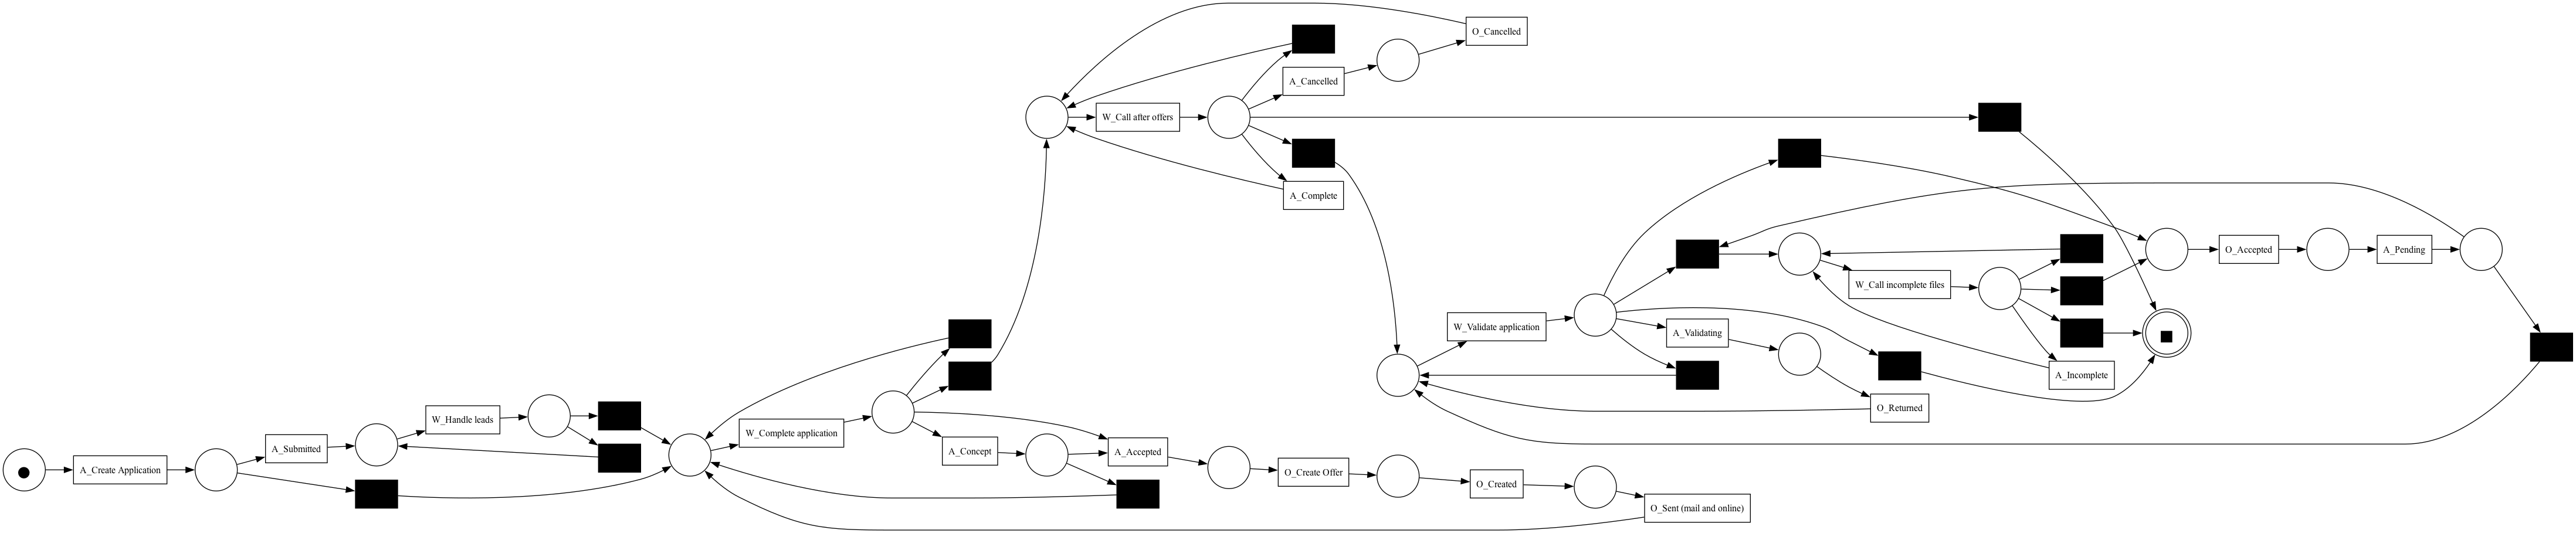

In [13]:

#PETRI-NETZ ERSTELLUNG & EXPORT
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.objects.petri_net.exporter import exporter as pnml_exporter

# Stelle sicher, dass das Modell existiert
if 'net_hm' not in locals():
    print("Petri-Netz nicht gefunden. Führe zuerst Cell 5 aus!")
else:
    print(f"Petri-Netz Details:")
    print(f"Places: {len(net_hm.places)}")
    print(f"Transitions: {len(net_hm.transitions)}")
    print(f"Arcs: {len(net_hm.arcs)}")
    print(f"Initial Marking: {len(im_hm)}")
    print(f"Final Markings: {len(fm_hm)}")
    
    # Zeige alle Transitions (Aktivitäten)
    print(f"Transitions (Aktivitäten)")
    transitions_list = [t.label for t in net_hm.transitions if t.label is not None]
    for i, trans in enumerate(sorted(set(transitions_list)), 1):
        print(f"  {i:2d}. {trans}")
    
    # Visualisiere das Petri-Netz
    print(f"Visualisierung")
    gviz_pn = pn_visualizer.apply(
        net_hm, im_hm, fm_hm,
        parameters={
            pn_visualizer.Variants.WO_DECORATION.value.Parameters.FORMAT: "png"
        }
    )
    
    # Speichere als PNG
    os.makedirs("output", exist_ok=True)
    pn_visualizer.save(gviz_pn, "output/petri_net_final.png")
    print(f"PNG gespeichert: output/petri_net_final.png")
    
    # Zeige das Petri-Netz an
    try:
        from IPython.display import Image, display
        display(Image(gviz_pn.render()))
    except:
        print(f"Verwende pn_visualizer.view(gviz_pn) zum Anzeigen")


In [14]:
# BPMN-MODELL EVALUIERUNG: Fitness & Precision
from pm4py.objects.bpmn.importer import importer as bpmn_importer
from pm4py.objects.conversion.bpmn import converter as bpmn_converter
from pm4py.algo.evaluation.replay_fitness import algorithm as fitness_evaluator
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator
from pm4py.algo.evaluation.replay_fitness.algorithm import Variants as FitnessVariants
from pm4py.algo.evaluation.precision.algorithm import Variants as PrecisionVariants
from pm4py.util.constants import PARAMETER_CONSTANT_ACTIVITY_KEY, PARAMETER_CONSTANT_CASEID_KEY
from pm4py.objects.conversion.log import converter as log_converter

# Pfad zum BPMN-Modell
BPMN_PATH = "/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/BPI-Challenge-2017/bpmn/_bpmn2017.bpmn"

# Stelle sicher, dass event_log existiert
if 'event_log' not in locals():
    print("Konvertiere log_df zu EventLog...")
    event_log = log_converter.apply(log_df, variant=log_converter.Variants.TO_EVENT_LOG)
    print(f"EventLog erstellt: {len(event_log):,} Fälle")

# Ursprüngliches Event Log (alle Fälle)
EVALUATION_LOG = event_log
EVALUATION_LOG_NAME = "URSPRÜNGLICHES Event Log"

print(f"EVALUATION: Das BPMN wird auf dem {EVALUATION_LOG_NAME} getestet")
print(f"Anzahl Fälle: {len(EVALUATION_LOG):,}")

# Lade das BPMN-Modell
print(f"Lade BPMN-Modell: {BPMN_PATH}")
try:
    bpmn_graph = bpmn_importer.apply(BPMN_PATH)
    print("BPMN-Modell erfolgreich geladen")
except Exception as e:
    print(f"Fehler beim Laden des BPMN-Modells: {e}")
    raise

# Konvertiere BPMN zu Petri-Netz (für Evaluation benötigt)
print("Konvertiere BPMN zu Petri-Netz")
try:
    net_bpmn, im_bpmn, fm_bpmn = bpmn_converter.apply(bpmn_graph)
    print(f"BPMN zu Petri-Netz konvertiert")
    print(f"Places: {len(net_bpmn.places)}")
    print(f"Transitions: {len(net_bpmn.transitions)}")
    print(f"Arcs: {len(net_bpmn.arcs)}")
except Exception as e:
    print(f"Fehler bei der Konvertierung: {e}")
    raise

# Zeige Aktivitäten im BPMN-Modell
print(f"Aktivitäten im BPMN-Modell")
transitions_bpmn = [t.label for t in net_bpmn.transitions if t.label is not None]
print(f"Anzahl Aktivitäten: {len(transitions_bpmn)}")
for i, trans in enumerate(sorted(set(transitions_bpmn)), 1):
    print(f"  {i:2d}. {trans}")

# Parameter für Evaluation
parameters_eval = {
    FitnessVariants.TOKEN_BASED.value.Parameters.ACTIVITY_KEY: 'concept:name',
    PARAMETER_CONSTANT_ACTIVITY_KEY: 'concept:name',
    PARAMETER_CONSTANT_CASEID_KEY: 'case:concept:name'
}

# Berechne Fitness
print(f"Berechne Fitness (Token-Based Replay)")
fitness_result = fitness_evaluator.apply(
    EVALUATION_LOG, net_bpmn, im_bpmn, fm_bpmn,
    variant=FitnessVariants.TOKEN_BASED,
    parameters=parameters_eval
)

# Berechne Precision
print(f"Berechne Precision (ETConformance Token)")
precision_result = precision_evaluator.apply(
    EVALUATION_LOG, net_bpmn, im_bpmn, fm_bpmn,
    variant=PrecisionVariants.ETCONFORMANCE_TOKEN,
    parameters={
        'activity_key': 'concept:name',
        'case_id_key': 'case:concept:name'
    }
)

# Berechne Generalization
print(f"Berechne Generalization")
generalization_result = generalization_evaluator.apply(
    EVALUATION_LOG, net_bpmn, im_bpmn, fm_bpmn
)

# Berechne Simplicity
print(f"Berechne Simplicity")
simplicity_result = simplicity_evaluator.apply(net_bpmn)

# Ergebnisse
print(f"""
METRIKEN:

Fitness (log_fitness):  {fitness_result.get('log_fitness', 0):.4f} ({fitness_result.get('log_fitness', 0)*100:.2f}%)
Precision:               {precision_result:.4f} ({precision_result*100:.2f}%)
Generalization:         {generalization_result:.4f} ({generalization_result*100:.2f}%)
Simplicity:             {simplicity_result:.4f}
Simplicity (Nodes):     {len(net_bpmn.places) + len(net_bpmn.transitions)}
Simplicity (Arcs):      {len(net_bpmn.arcs)}

ETAILS:
Evaluations-Log:         {EVALUATION_LOG_NAME} ({len(EVALUATION_LOG):,} Fälle)
Aktivitäten im Modell:   {len(transitions_bpmn)}
Aktivitäten im Log:      {log_df['concept:name'].nunique()}

{'FITNESS ≥ 80%' if fitness_result.get('log_fitness', 0) >= 0.80 else 'FITNESS < 80%'}
{'PRECISION ≥ 60%' if precision_result >= 0.60 else 'PRECISION < 60%'}
""")

# Zusätzliche Fitness-Metriken
if 'perc_fit_traces' in fitness_result:
    perc_fit = fitness_result.get('perc_fit_traces', 0)
    # Check if it's already a percentage (>= 1) or a decimal (< 1)
    if perc_fit >= 1:
        # Already a percentage, use as is
        perc_fit_display = perc_fit
    else:
        # Decimal format, convert to percentage
        perc_fit_display = perc_fit * 100
    print(f"  - Prozent perfekt passender Traces: {perc_fit_display:.2f}%")
if 'average_trace_fitness' in fitness_result:
    print(f"Durchschnittliche Trace-Fitness: {fitness_result.get('average_trace_fitness', 0):.4f}")



EVALUATION: Das BPMN wird auf dem URSPRÜNGLICHES Event Log getestet
Anzahl Fälle: 31,411
Lade BPMN-Modell: /Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/BPI-Challenge-2017/bpmn/_bpmn2017.bpmn
BPMN-Modell erfolgreich geladen
Konvertiere BPMN zu Petri-Netz
BPMN zu Petri-Netz konvertiert
Places: 26
Transitions: 44
Arcs: 88
Aktivitäten im BPMN-Modell
Anzahl Aktivitäten: 22
   1. A_Accepted
   2. A_Cancelled
   3. A_Complete
   4. A_Concept
   5. A_Create Application
   6. A_Denied
   7. A_Incomplete
   8. A_Pending
   9. A_Submitted
  10. A_Validating
  11. O_Accepted
  12. O_Cancelled
  13. O_Create Offer
  14. O_Created
  15. O_Returned
  16. O_Sent
  17. O_Sent (mail and online)
  18. W_Call after offers
  19. W_Call incomplete files
  20. W_Complete application
  21. W_Handle leads
  22. W_Validate application
Berechne Fitness (Token-Based Replay)


replaying log with TBR, completed traces :: 100%|██████████| 15844/15844 [00:31<00:00, 507.23it/s]


Berechne Precision (ETConformance Token)


replaying log with TBR, completed traces :: 100%|██████████| 263029/263029 [02:32<00:00, 1726.11it/s]


Berechne Generalization


replaying log with TBR, completed traces :: 100%|██████████| 15844/15844 [00:32<00:00, 489.68it/s]


Berechne Simplicity

METRIKEN:

Fitness (log_fitness):  0.9564 (95.64%)
Precision:               0.5751 (57.51%)
Generalization:         0.9481 (94.81%)
Simplicity:             0.6604
Simplicity (Nodes):     70
Simplicity (Arcs):      88

ETAILS:
Evaluations-Log:         URSPRÜNGLICHES Event Log (31,411 Fälle)
Aktivitäten im Modell:   22
Aktivitäten im Log:      26

FITNESS ≥ 80%
PRECISION < 60%

  - Prozent perfekt passender Traces: 4.75%
Durchschnittliche Trace-Fitness: 0.9540
